In [8]:
from numpy import sqrt, linspace, where
from scipy.optimize import fsolve
from scipy.special import jv, kv
import matplotlib.pyplot as plt

In [9]:
V = 8
l = 0

In [10]:
def eigen_eq_for_LP_lm(V, l):
    def func_to_cal(u):
        w = sqrt(V*V - u*u)
        return jv(l - 1, u) / jv(l, u) + (w / u) * kv(l - 1, w) / kv(l, w)
    return func_to_cal

In [11]:
def eq_left_side(V, l):
    def lhs(u):
        w = sqrt(V*V - u*u)
        return jv(l - 1, u) / jv(l, u)
    return lhs

In [12]:
def eq_right_side(V, I):
    def rhs(u):
        w = sqrt(V*V - u*u)
        return -(w / u) * kv(l - 1, w) / kv(l, w)
    return rhs

In [13]:
root = fsolve(eigen_eq_for_LP_lm(V,l), [2.1, 5.2, 7.0])
print(root)

[2.13458308 4.86579678 7.45285662]


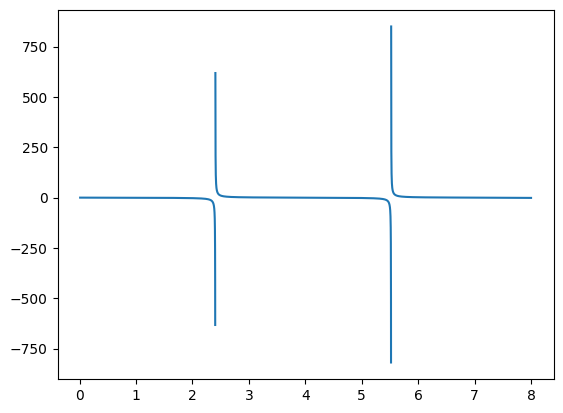

In [34]:
u = linspace(0.01, V, 10000)
lhs = eq_left_side(V, l)(u)
plot_limit = 1000
mlhs = where(abs(lhs) < plot_limit, lhs, None)
plt.plot(u, mlhs)

C:\Users\jkkow\AppData\Local\Temp\ipykernel_7144\129632344.py:4: RuntimeWarning: invalid value encountered in multiply
  return -(w / u) * kv(l - 1, w) / kv(l, w)


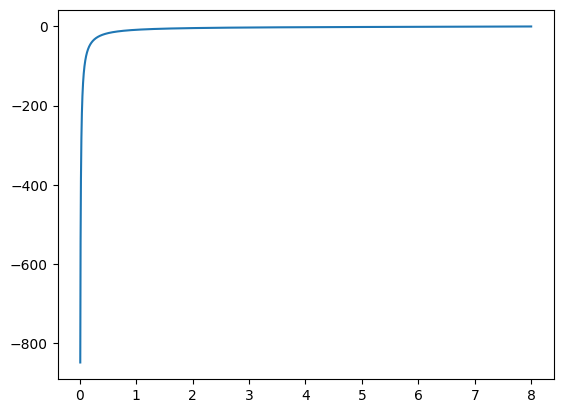

In [35]:
rhs = eq_right_side(V, l)
rhs = rhs(u)
mrhs = where(abs(rhs) < plot_limit, rhs, None)
plt.plot(u, mrhs)

(0.0, 8.0)

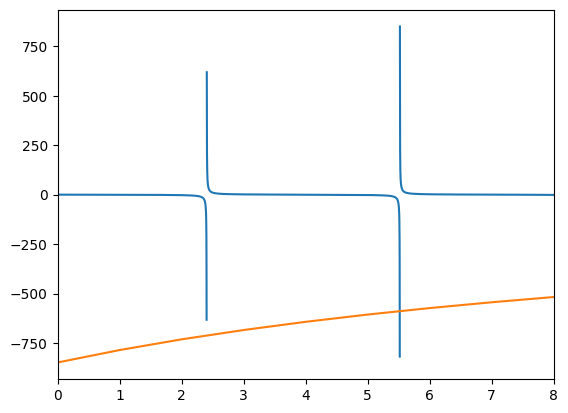

In [36]:
plt.plot(u, mlhs, mrhs)
plt.xlim(0, 8)